# Deep Learning

This notebook contains the steps for training a Multilayer Perceptron (MLP) on the PV dataset, as well as it's analysis and comparison with the machine learning models used in the other notebooks.


In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import os
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score

# Define the file path relative to the current notebook directory
base_path = os.path.join("..", "data", "processed")
results_path = os.path.join("..", "results")
os.makedirs(results_path, exist_ok=True)

# Load preprocessed data
X_train = pd.read_csv(os.path.join(base_path, "X_train_scaled.csv"))
X_test = pd.read_csv(os.path.join(base_path, "X_test_scaled.csv"))
y_efficiency_train = pd.read_csv(os.path.join(base_path, "y_efficiency_train.csv"))
y_efficiency_test = pd.read_csv(os.path.join(base_path, "y_efficiency_test.csv"))

# Ensure targets are arrays (for compatibility with TensorFlow/Keras)
y_efficiency_train = np.array(y_efficiency_train).flatten()
y_efficiency_test = np.array(y_efficiency_test).flatten()

# Use part of the training data as validation data
val_size = int(0.2 * len(X_train))  # Use 20% of the training data for validation
X_val = X_train[:val_size]
y_val = y_efficiency_train[:val_size]
X_train = X_train[val_size:]
y_train = y_efficiency_train[val_size:]

# Define the model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='linear')  # Regression output
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

# Define early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stopping]
)

# Evaluate the model
test_loss, test_mae = model.evaluate(X_test, y_efficiency_test)
print(f"Test Loss: {test_loss}, Test MAE: {test_mae}")

# Save the model and predictions
model.save(os.path.join(results_path, "efficiency_model.h5"))

# Predict on the test set and save results
y_pred = model.predict(X_test)
r2 = r2_score(y_efficiency_test, y_pred)
print(f"R-squared: {r2}")
pd.DataFrame(y_pred, columns=["Predicted Efficiency"]).to_csv(
    os.path.join(results_path, "cnn_predictions.csv"), index=False
)

c:\Users\Utilizador\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 0.0161 - mae: 0.0723 - val_loss: 1.7382e-04 - val_mae: 0.0109
Epoch 2/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 2.1790e-04 - mae: 0.0111 - val_loss: 3.4398e-05 - val_mae: 0.0045
Epoch 3/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 1.0834e-04 - mae: 0.0077 - val_loss: 5.6274e-05 - val_mae: 0.0061
Epoch 4/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 7.6657e-05 - mae: 0.0063 - val_loss: 3.6790e-05 - val_mae: 0.0045
Epoch 5/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 5.9016e-05 - mae: 0.0055 - val_loss: 6.3455e-05 - val_mae: 0.0060
Epoch 6/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - loss: 5.2091e-05 - mae: 0.0050 - val_loss: 6.1716e-05 - val_mae: 0.0055
Epoch 7/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 4.4308e-05 - mae: 0.0046 - val_loss: 5.0639e-05 - val_mae: 0.0051
Epoch 8/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 3.8991e-05 - mae: 0.0043 - val_loss: 4

Test Loss: 3.373788422322832e-05, Test MAE: 0.0044189998880028725
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
R-squared: 0.9685330979992754


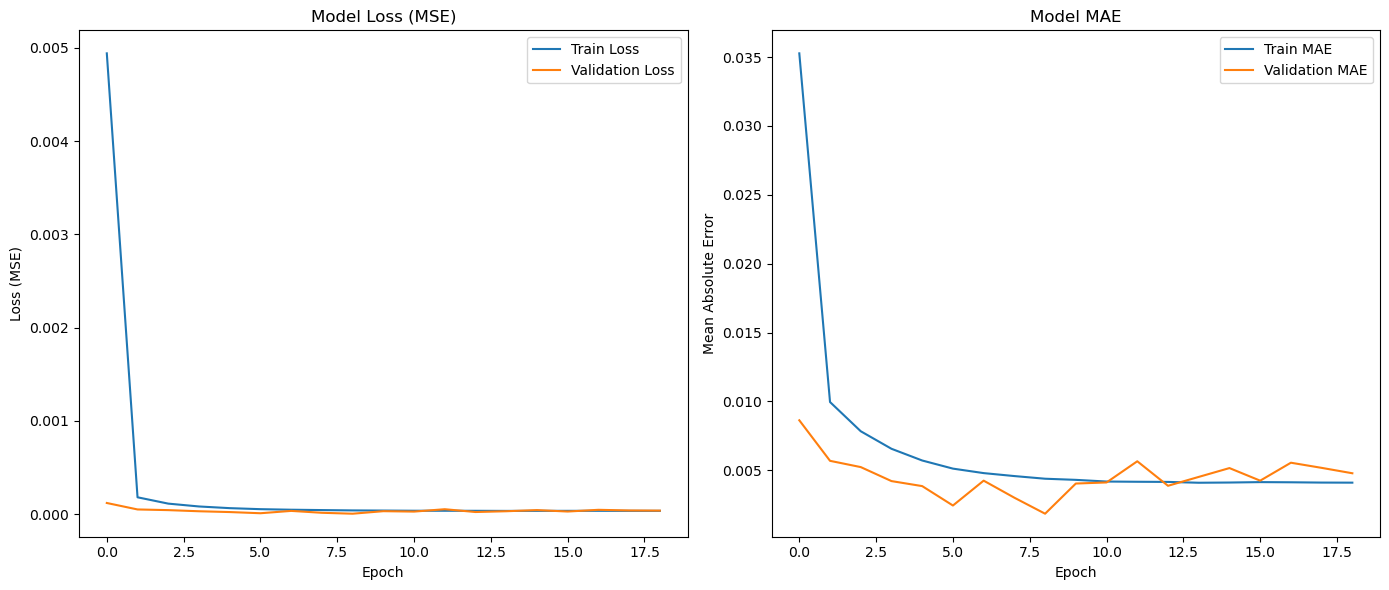

In [3]:
import matplotlib.pyplot as plt

# Plot training & validation loss values
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend(loc='upper right')

# Plot training & validation MAE values
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model MAE')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [7]:
# Define the file path relative to the current notebook directory
base_path = os.path.join("..", "data", "processed")
results_path = os.path.join("..", "results")
os.makedirs(results_path, exist_ok=True)

# Load preprocessed data
X_train = pd.read_csv(os.path.join(base_path, "X_train_scaled.csv"))
X_test = pd.read_csv(os.path.join(base_path, "X_test_scaled.csv"))
y_efficiency_train = pd.read_csv(os.path.join(base_path, "y_efficiency_train.csv"))
y_efficiency_test = pd.read_csv(os.path.join(base_path, "y_efficiency_test.csv"))
y_efficiency_level_train = pd.read_csv(os.path.join(base_path, "y_efficiency_level_train.csv"))
y_efficiency_level_test = pd.read_csv(os.path.join(base_path, "y_efficiency_level_test.csv"))

# Ensure targets are arrays (for compatibility with TensorFlow/Keras)
y_efficiency_level_train = np.array(y_efficiency_level_train).flatten()
y_efficiency_level_test = np.array(y_efficiency_level_test).flatten()

label_mapping = {"extremely_bad": 0, "bad": 1, "moderate": 2, "good": 3}

# Function to map labels
def map_labels(labels):
    mapped_labels = []
    for label in labels:
        if label in label_mapping:
            mapped_labels.append(label_mapping[label])
        else:
            raise ValueError(f"Unknown label: {label}")
    return np.array(mapped_labels)

# Apply the function to your label arrays
y_efficiency_level_train = map_labels(y_efficiency_level_train)
y_efficiency_level_test = map_labels(y_efficiency_level_test)

# Use part of the training data as validation data
val_size = int(0.2 * len(X_train))  # Use 20% of the training data for validation
X_val = X_train[:val_size]
y_val = y_efficiency_level_train[:val_size]
X_train = X_train[val_size:]
y_train = y_efficiency_level_train[val_size:]

# Define the model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(4, activation='softmax')  # 4 neurons for 4 classes
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Define early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(
    X_train, y_train,  # y_train should contain class indices (e.g., 0, 1, 2, 3)
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=32,
    callbacks=[early_stopping]
)

# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test, y_efficiency_level_test)
print(f"Test Loss: {test_loss}, Test Accuracy: {test_accuracy}")

c:\Users\Utilizador\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/40
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - accuracy: 0.8350 - loss: 0.4230 - val_accuracy: 0.9668 - val_loss: 0.0894
Epoch 2/40
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9507 - loss: 0.1159 - val_accuracy: 0.9797 - val_loss: 0.0549
Epoch 3/40
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9666 - loss: 0.0829 - val_accuracy: 0.9831 - val_loss: 0.0432
Epoch 4/40
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9722 - loss: 0.0663 - val_accuracy: 0.9853 - val_loss: 0.0371
Epoch 5/40
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9754 - loss: 0.0597 - val_accuracy: 0.9859 - val_loss: 0.0343
Epoch 6/40
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9781 - loss: 0.0544 - val_accuracy: 0.9882 - val_loss: 0.0316
Epoch 7/40
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9792 - loss: 0.0516 - val_accuracy: 0.9891 - val_loss: 0.0292
Epoch 8/40
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9803 - loss: 0

## Deep Learning Model Analysis

The deep learning model used for regression demonstrated accuracy; however, it did not outperform the other machine learning models implemented in previous notebooks. The same conclusion applies to the deep learning model used for classification. We could try to improve the model but, given these results, there is no added benefit in introducing additional complexity and training time with deep learning. Therefore, we recommend relying on the machine learning models suggested in the other notebooks for these tasks.